# **CNN**

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [3]:
#Doc du lieu MNIST
mmist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mmist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [4]:
num_classes = 10
input_shape = (28 , 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test  = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


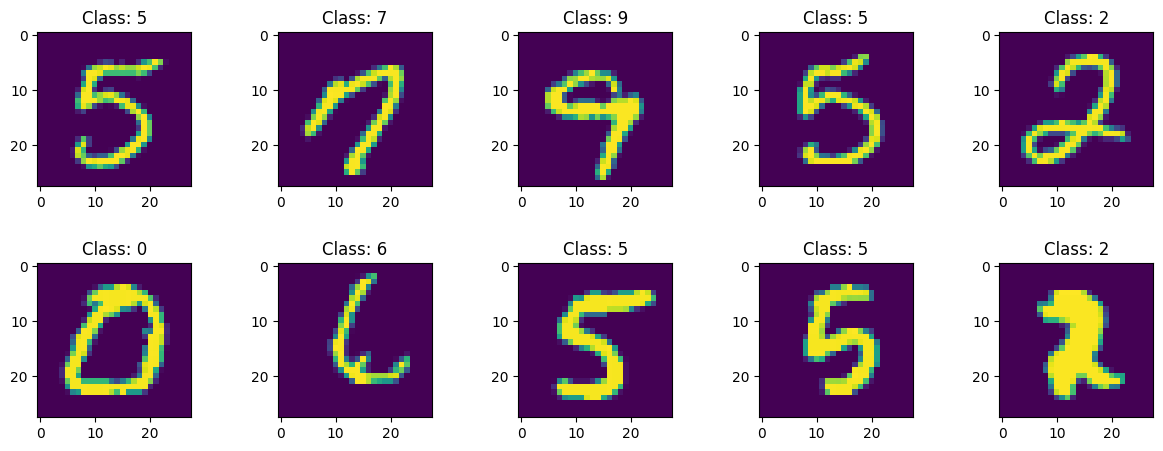

In [6]:
#Truc quan hoa 10 anh dau tien
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class: '+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [7]:
#Chuyen gia tri nhan thanh one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [10]:
#Xay dung mo hinh CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#Huan luyen mo hinh CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8558 - loss: 0.5759 - val_accuracy: 0.9460 - val_loss: 0.1980
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - accuracy: 0.9591 - loss: 0.1416 - val_accuracy: 0.9625 - val_loss: 0.1277
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.9714 - loss: 0.0979 - val_accuracy: 0.9670 - val_loss: 0.1018
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.9776 - loss: 0.0749 - val_accuracy: 0.9700 - val_loss: 0.0944
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.9801 - loss: 0.0617 - val_accuracy: 0.9730 - val_loss: 0.0848
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.9826 - loss: 0.0542 - val_accuracy: 0.9750 - val_loss: 0.0771
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9858 - loss: 0.0453 - val_accuracy: 0.9755 - val_loss: 0.0806
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.9878 - loss: 0.0380 

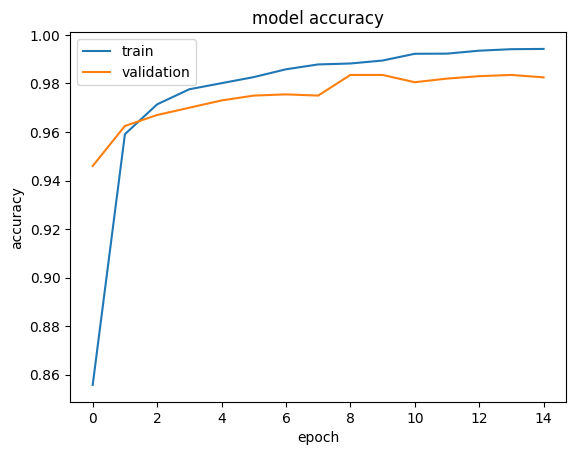

In [14]:
#Danh gia mo hinh CNN
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

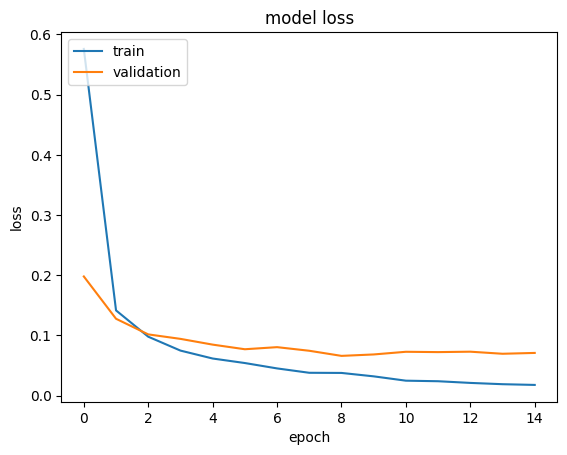

In [15]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [16]:
#Danh gia mo hinh CNN thu nghiem tren file test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss', score[0])
print('Test accuracy', score[1])

313/313 - 2s - 8ms/step - accuracy: 0.9837 - loss: 0.0559
Test loss 0.05593138188123703
Test accuracy 0.9836983680725098


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[4.4780700e-06 2.1792760e-03 9.9777383e-01 8.1228267e-11 8.7808903e-19
  4.7691482e-14 4.2314932e-05 2.4883022e-16 1.6071391e-08 5.4992130e-21]]
2 2


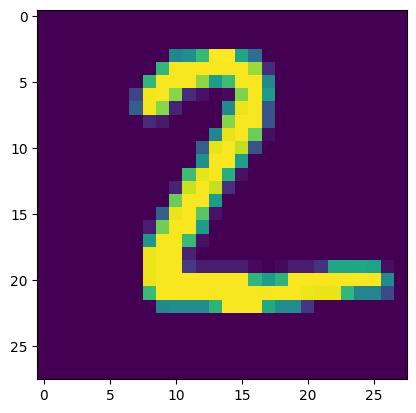

In [21]:
#Du bao nhan cho anh su dung CNN
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [22]:
#Luu tham so mo hinh CNN
model.save_weights('cnn.weights.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
[[1.92946274e-07 9.99928951e-01 1.41336363e-06 2.63050470e-08
  4.04532875e-05 1.40343355e-08 4.17838282e-06 9.44823569e-06
  1.53540423e-05 1.40011016e-08]]
1 1


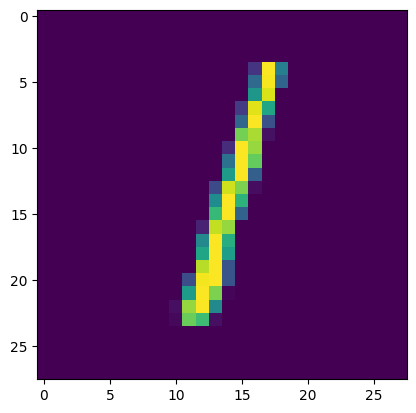

In [24]:
#Nap lai mo hinh va tham so
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()